# 🚀 YT8M Genre Classifier — Stage 5: Training
Обучение YT8MClassifier с FocalLoss, OneCycleLR и early stopping по val macro-F1.

In [1]:
# ============================================================
# STAGE 5.0 — Импорты и восстановление из Stage 3/4
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import json, time
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import f1_score, classification_report, confusion_matrix

STAGE3_DIR = Path(r'C:\src\ai\video_classifier\data2\stage3')
STAGE4_DIR = Path(r'C:\src\ai\video_classifier\data2\stage4')
STAGE5_DIR = Path(r'C:\src\ai\video_classifier\data2\stage5')
STAGE5_DIR.mkdir(parents=True, exist_ok=True)

with open(STAGE3_DIR / 'config.json') as f:
    cfg = json.load(f)

DIM_VISUAL = cfg['dim_visual']
DIM_AUDIO  = cfg['dim_audio']
N_CLASSES  = cfg['n_classes']
GENRES     = cfg['genres']
BATCH_SIZE = cfg['batch_size']
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

plt.rcParams.update({
    'figure.facecolor':'#0F1117','axes.facecolor':'#1A1D2E',
    'axes.edgecolor':'#2E3250','axes.labelcolor':'#C8D0F0',
    'axes.titlecolor':'#FFFFFF','xtick.color':'#8890B0',
    'ytick.color':'#8890B0','text.color':'#C8D0F0',
    'grid.color':'#2E3250','grid.linestyle':'--','grid.alpha':0.4,
    'figure.dpi':130,
})

print(f'DEVICE = {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    = {torch.cuda.get_device_name(0)}')


DEVICE = cpu


In [2]:
# ============================================================
# STAGE 5.1 — Копируем классы из Stage 3 и 4
# ============================================================

class VideoDataset(Dataset):
    def __init__(self, X_visual, X_audio, y, augment=False):
        self.Xv  = torch.tensor(X_visual, dtype=torch.float32)
        self.Xa  = torch.tensor(X_audio,  dtype=torch.float32)
        self.y   = torch.tensor(y,        dtype=torch.long)
        self.aug = augment
    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        xv = self.Xv[idx].clone()
        xa = self.Xa[idx].clone()
        if self.aug:
            xv = xv + torch.randn_like(xv) * 0.02
            xa = xa + torch.randn_like(xa) * 0.03
            if torch.rand(1).item() < 0.5:
                xv = xv * (torch.rand_like(xv) > 0.05).float()
        return xv, xa, self.y[idx]


class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim), nn.BatchNorm1d(dim), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(dim, dim), nn.BatchNorm1d(dim),
        )
        self.act = nn.GELU()
    def forward(self, x): return self.act(x + self.net(x))

class VisualBranch(nn.Module):
    def __init__(self, in_dim=1024, embed_dim=256, dropout=0.3):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(in_dim, embed_dim), nn.BatchNorm1d(embed_dim), nn.GELU())
        self.res1 = ResidualBlock(embed_dim, dropout)
        self.res2 = ResidualBlock(embed_dim, dropout)
    def forward(self, x): return self.res2(self.res1(self.proj(x)))

class AudioBranch(nn.Module):
    def __init__(self, in_dim=128, embed_dim=128, dropout=0.3):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(in_dim, embed_dim), nn.BatchNorm1d(embed_dim), nn.GELU())
        self.res  = ResidualBlock(embed_dim, dropout)
    def forward(self, x): return self.res(self.proj(x))

class CrossModalAttention(nn.Module):
    def __init__(self, visual_dim=256, audio_dim=128, fusion_dim=256, n_heads=4, dropout=0.2):
        super().__init__()
        self.proj_v = nn.Linear(visual_dim, fusion_dim)
        self.proj_a = nn.Linear(audio_dim,  fusion_dim)
        self.attn   = nn.MultiheadAttention(fusion_dim, n_heads, dropout=dropout, batch_first=True)
        self.norm   = nn.LayerNorm(fusion_dim)
        self.out_dim = fusion_dim * 2
    def forward(self, v, a):
        tokens = torch.cat([self.proj_v(v).unsqueeze(1), self.proj_a(a).unsqueeze(1)], dim=1)
        out, attn_w = self.attn(tokens, tokens, tokens)
        out = self.norm(out + tokens)
        return out.reshape(out.size(0), -1), attn_w

class YT8MClassifier(nn.Module):
    def __init__(self, dim_visual=1024, dim_audio=128, n_classes=12,
                 visual_embed=256, audio_embed=128, fusion_dim=256,
                 n_heads=4, dropout=0.35):
        super().__init__()
        self.visual_branch = VisualBranch(dim_visual, visual_embed, dropout)
        self.audio_branch  = AudioBranch(dim_audio,  audio_embed,  dropout)
        self.fusion        = CrossModalAttention(visual_embed, audio_embed, fusion_dim, n_heads, dropout*0.5)
        fused_dim = self.fusion.out_dim
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(dropout*0.5),
            nn.Linear(128, n_classes),
        )
    def forward(self, xv, xa):
        fused, attn_w = self.fusion(self.visual_branch(xv), self.audio_branch(xa))
        return self.classifier(fused), attn_w

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, logits, targets):
        ce    = F.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        focal = (1 - torch.exp(-ce)) ** self.gamma * ce
        return focal.mean()

print('✅ Все классы определены')


✅ Все классы определены


In [3]:
# ============================================================
# STAGE 5.2 — DataLoaders
# ============================================================
Xv_train = np.load(STAGE3_DIR / 'Xv_train.npy')
Xv_val   = np.load(STAGE3_DIR / 'Xv_val.npy')
Xv_test  = np.load(STAGE3_DIR / 'Xv_test.npy')
Xa_train = np.load(STAGE3_DIR / 'Xa_train.npy')
Xa_val   = np.load(STAGE3_DIR / 'Xa_val.npy')
Xa_test  = np.load(STAGE3_DIR / 'Xa_test.npy')
y_train  = np.load(STAGE3_DIR / 'y_train.npy')
y_val    = np.load(STAGE3_DIR / 'y_val.npy')
y_test   = np.load(STAGE3_DIR / 'y_test.npy')

class_weights = torch.load(STAGE3_DIR / 'class_weights.pt', weights_only=True).to(DEVICE)

train_ds = VideoDataset(Xv_train, Xa_train, y_train, augment=True)
val_ds   = VideoDataset(Xv_val,   Xa_val,   y_val,   augment=False)
test_ds  = VideoDataset(Xv_test,  Xa_test,  y_test,  augment=False)

sample_weights = torch.tensor(cfg['class_weights'], dtype=torch.float32)[y_train]
sampler = WeightedRandomSampler(sample_weights, len(train_ds), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,    num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,    num_workers=0)

print(f'✅ DataLoaders: train={len(train_loader)} val={len(val_loader)} test={len(test_loader)} steps')


✅ DataLoaders: train=98 val=21 test=21 steps


In [4]:
# ============================================================
# STAGE 5.3 — Training loop
# ============================================================
N_EPOCHS     = 100
LR           = 3e-4
WEIGHT_DECAY = 1e-3
PATIENCE     = 15

model     = YT8MClassifier(DIM_VISUAL, DIM_AUDIO, N_CLASSES).to(DEVICE)
criterion = FocalLoss(alpha=class_weights, gamma=2.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR,
    epochs=N_EPOCHS, steps_per_epoch=len(train_loader),
    pct_start=0.1, anneal_strategy='cos',
)

history = {'train_loss':[], 'val_loss':[], 'val_acc':[], 'val_f1':[], 'lr':[]}
best_f1, best_epoch, patience_cnt = 0.0, 0, 0

def evaluate(loader):
    model.eval()
    total_loss, all_pred, all_true = 0.0, [], []
    with torch.no_grad():
        for xv, xa, yt in loader:
            xv, xa, yt = xv.to(DEVICE), xa.to(DEVICE), yt.to(DEVICE)
            logits, _  = model(xv, xa)
            total_loss += criterion(logits, yt).item()
            all_pred.extend(logits.argmax(dim=1).cpu().tolist())
            all_true.extend(yt.cpu().tolist())
    avg_loss = total_loss / len(loader)
    acc      = np.mean(np.array(all_pred) == np.array(all_true))
    macro_f1 = f1_score(all_true, all_pred, average='macro', zero_division=0)
    return avg_loss, acc, macro_f1

print(f'🚀 Старт обучения: {N_EPOCHS} эпох, patience={PATIENCE}')
print(f'   {"Epoch":>5}  {"TrainLoss":>10}  {"ValLoss":>9}  {"ValAcc":>7}  {"ValF1":>7}  {"LR":>9}  {""}')
print('   ' + '-' * 68)

t_start = time.time()
for epoch in range(1, N_EPOCHS + 1):
    # --- Train ---
    model.train()
    train_loss = 0.0
    for xv, xa, yt in train_loader:
        xv, xa, yt = xv.to(DEVICE), xa.to(DEVICE), yt.to(DEVICE)
        optimizer.zero_grad()
        logits, _ = model(xv, xa)
        loss = criterion(logits, yt)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # --- Validate ---
    val_loss, val_acc, val_f1 = evaluate(val_loader)
    cur_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    history['lr'].append(cur_lr)

    marker = ''
    if val_f1 > best_f1:
        best_f1    = val_f1
        best_epoch = epoch
        patience_cnt = 0
        torch.save(model.state_dict(), STAGE5_DIR / 'best_model.pt')
        marker = '  ✅ best'
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'\n   Early stopping на эпохе {epoch} (patience={PATIENCE})')
            break

    if epoch % 5 == 0 or epoch == 1:
        elapsed = time.time() - t_start
        print(f'   {epoch:>5}  {train_loss:>10.4f}  {val_loss:>9.4f}  '
              f'{val_acc*100:>6.2f}%  {val_f1:>7.4f}  {cur_lr:>9.2e}{marker}')

print(f'\n✅ Обучение завершено!')
print(f'   Best val F1 : {best_f1:.4f}  (epoch {best_epoch})')
print(f'   Время       : {(time.time()-t_start)/60:.1f} мин')


🚀 Старт обучения: 100 эпох, patience=15
   Epoch   TrainLoss    ValLoss   ValAcc    ValF1         LR  
   --------------------------------------------------------------------
       1      1.9996     1.7946   17.44%   0.1522   1.91e-05  ✅ best
       5      0.4018     0.2937   81.61%   0.8217   1.56e-04  ✅ best
      10      0.0661     0.2430   85.20%   0.8580   3.00e-04  ✅ best
      15      0.0286     0.2779   84.83%   0.8550   2.98e-04
      20      0.0161     0.3170   84.68%   0.8530   2.91e-04
      25      0.0104     0.3407   84.68%   0.8547   2.80e-04

   Early stopping на эпохе 27 (patience=15)

✅ Обучение завершено!
   Best val F1 : 0.8580  (epoch 12)
   Время       : 4.9 мин


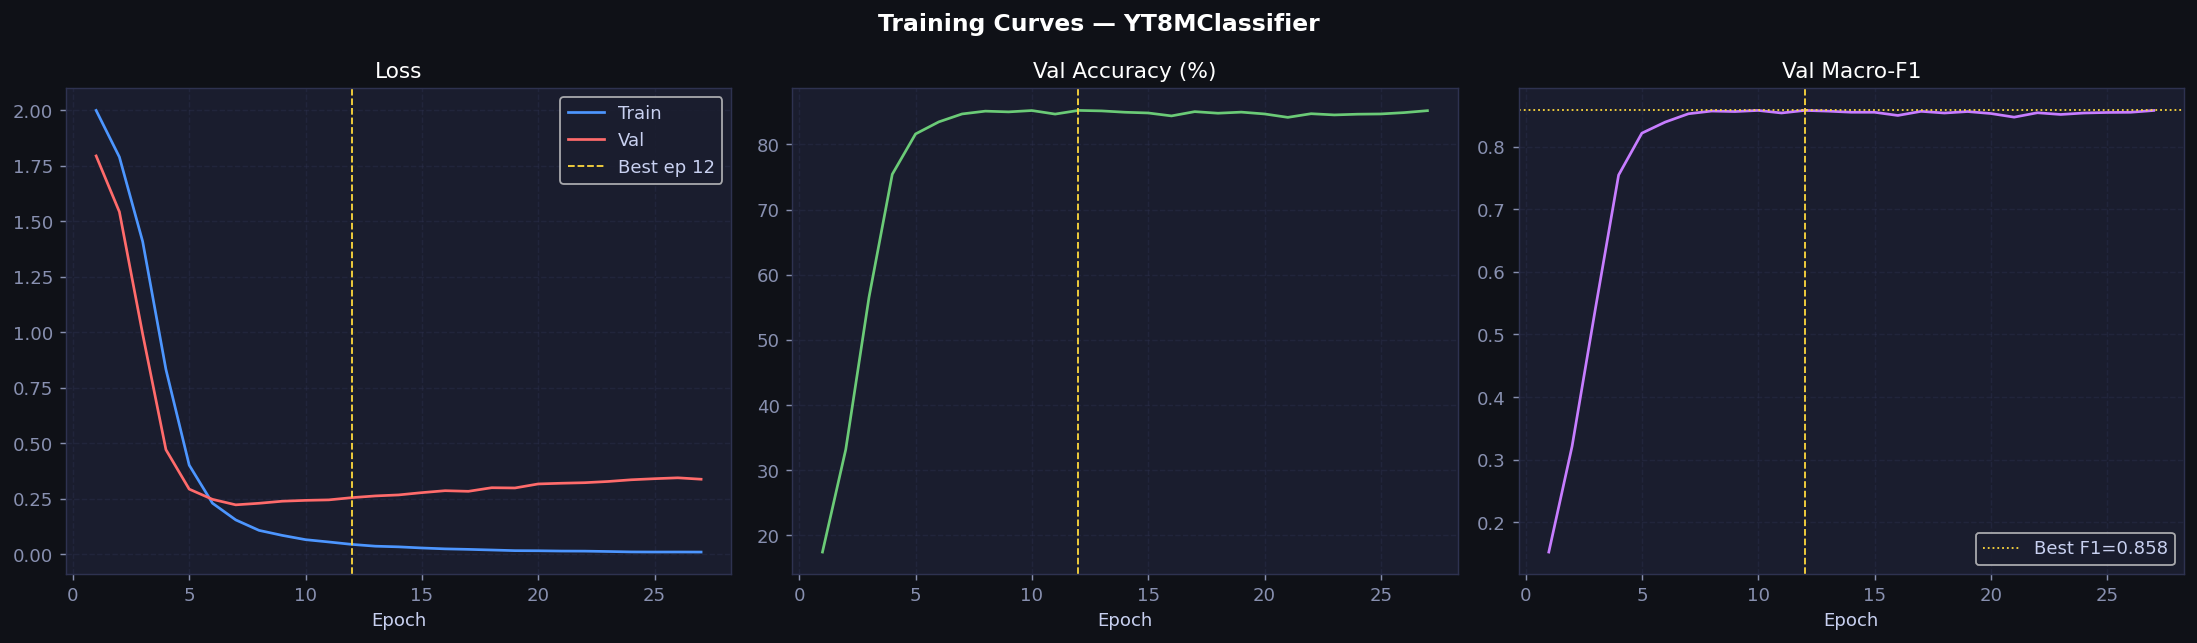

💾 training_curves.png сохранён


In [5]:
# ============================================================
# STAGE 5.4 — Кривые обучения
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Training Curves — YT8MClassifier', fontsize=13, color='white', fontweight='bold')
epochs_ran = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_ran, history['train_loss'], color='#4D96FF', lw=1.5, label='Train')
axes[0].plot(epochs_ran, history['val_loss'],   color='#FF6B6B', lw=1.5, label='Val')
axes[0].axvline(best_epoch, color='#FFD93D', ls='--', lw=1, label=f'Best ep {best_epoch}')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs_ran, [a*100 for a in history['val_acc']], color='#6BCB77', lw=1.5)
axes[1].axvline(best_epoch, color='#FFD93D', ls='--', lw=1)
axes[1].set_title('Val Accuracy (%)'); axes[1].set_xlabel('Epoch'); axes[1].grid(True)

axes[2].plot(epochs_ran, history['val_f1'], color='#C77DFF', lw=1.5)
axes[2].axvline(best_epoch, color='#FFD93D', ls='--', lw=1)
axes[2].axhline(best_f1, color='#FFD93D', ls=':', lw=1, label=f'Best F1={best_f1:.3f}')
axes[2].set_title('Val Macro-F1'); axes[2].set_xlabel('Epoch'); axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.savefig(STAGE5_DIR / 'training_curves.png', bbox_inches='tight', facecolor='#0F1117')
plt.show()
print('💾 training_curves.png сохранён')


       TEST RESULTS  (best epoch=12)
  Test Accuracy : 85.00%
  Test Macro-F1 : 0.8557
  KNN Baseline  : Acc=79.8%  F1=0.8034  (Stage 2)

  Жанр                F1    Prec     Rec       N
  --------------------------------------------
  Animals          0.877   0.881   0.872   509.0  █████████████
  Animation        0.872   0.925   0.825   509.0  █████████████
  Beauty           0.934   0.906   0.964   169.0  ██████████████
  Dance            0.859   0.820   0.902   509.0  ████████████
  Film             0.868   0.812   0.932   251.0  █████████████
  Food             0.882   0.901   0.862   509.0  █████████████
  Gaming           0.798   0.811   0.786   509.0  ███████████
  Music            0.777   0.815   0.743   509.0  ███████████
  Performance      0.759   0.755   0.762   509.0  ███████████
  Sports           0.866   0.857   0.874   509.0  ████████████
  Tech             0.875   0.840   0.913   345.0  █████████████
  Vehicles         0.903   0.904   0.902   509.0  █████████████


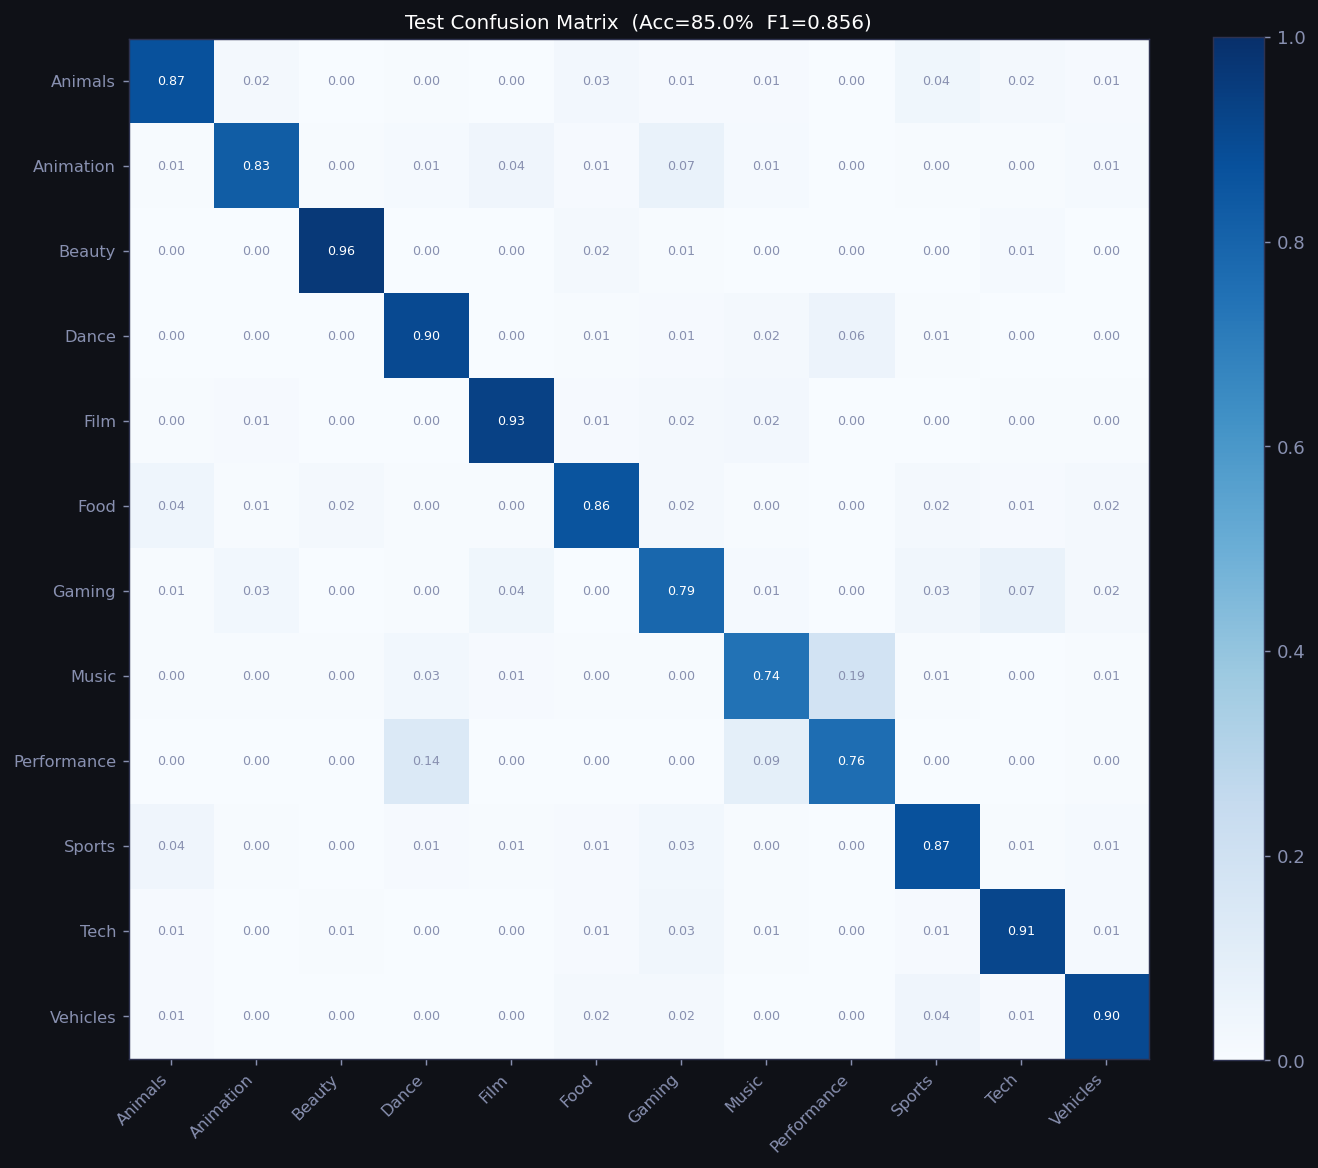


💾 Сохранено в C:\src\ai\video_classifier\data2\stage5
✅ Готово к Stage 6 — Error Analysis & Improvements


In [6]:
# ============================================================
# STAGE 5.5 — Тест на test set
# ============================================================
model.load_state_dict(torch.load(STAGE5_DIR / 'best_model.pt', weights_only=True))
test_loss, test_acc, test_f1 = evaluate(test_loader)

# Per-class отчёт
model.eval()
all_pred, all_true = [], []
with torch.no_grad():
    for xv, xa, yt in test_loader:
        logits, _ = model(xv.to(DEVICE), xa.to(DEVICE))
        all_pred.extend(logits.argmax(1).cpu().tolist())
        all_true.extend(yt.tolist())

report = classification_report(all_true, all_pred, target_names=GENRES, output_dict=True)

print('=' * 58)
print(f'       TEST RESULTS  (best epoch={best_epoch})')
print('=' * 58)
print(f'  Test Accuracy : {test_acc*100:.2f}%')
print(f'  Test Macro-F1 : {test_f1:.4f}')
print(f'  KNN Baseline  : Acc=79.8%  F1=0.8034  (Stage 2)')
print()
print(f'  {"Жанр":<14}  {"F1":>6}  {"Prec":>6}  {"Rec":>6}  {"N":>6}')
print('  ' + '-' * 44)
for genre in GENRES:
    r = report[genre]
    bar = chr(9608) * int(r['f1-score'] * 15)
    print(f'  {genre:<14}  {r["f1-score"]:>6.3f}  {r["precision"]:>6.3f}  '
          f'{r["recall"]:>6.3f}  {r["support"]:>6}  {bar}')
print('=' * 58)

# Confusion matrix
cm = confusion_matrix(all_true, all_pred, normalize='true')
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
ax.set_xticklabels(GENRES, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(GENRES, fontsize=9)
ax.set_title(f'Test Confusion Matrix  (Acc={test_acc*100:.1f}%  F1={test_f1:.3f})',
             fontsize=11, color='white')
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center',
                fontsize=7, color='white' if cm[i,j] > 0.5 else '#8890B0')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(STAGE5_DIR / 'test_confusion_matrix.png', bbox_inches='tight', facecolor='#0F1117')
plt.show()

# Сохраняем результаты
results = {
    'best_epoch'   : best_epoch,
    'best_val_f1'  : float(best_f1),
    'test_accuracy': float(test_acc),
    'test_macro_f1': float(test_f1),
    'test_loss'    : float(test_loss),
    'per_class_f1' : {g: float(report[g]['f1-score']) for g in GENRES},
    'history'      : history,
}
with open(STAGE5_DIR / 'results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f'\n💾 Сохранено в {STAGE5_DIR}')
print('✅ Готово к Stage 6 — Error Analysis & Improvements')
